# PoC MVP 1 — Malla dental → nube de puntos → 3D Gaussian Splatting (VTK)

**Issue 2** · Contraparte de datos: [`docs/research/dataset-teeth3ds.md`](../docs/research/dataset-teeth3ds.md) · Diseño: [`docs/architecture/multi-agent-pipeline.md`](../docs/architecture/multi-agent-pipeline.md)

**Objetivo del PoC:** validar el eslabón mínimo del pipeline *«malla 3D → campo gaussiano volumétrico»* con la librería fácil (**VTK**, `vtkGaussianSplatter`), y comprobar que la salida se puede **serializar al contrato** `core-schemas` (`TwinSnapshot` + `gaussian_field_ref`), para que el PoC no quede huérfano de la arquitectura.

**Qué NO es:** no es 3DGS entrenado (no hay optimización diferenciable ni armónicos esféricos); es un *splatting* de densidad clásico que hace de **banco de pruebas** de la tubería y de insumo para el **ADR 002 (render)** y el ADR de fusión. Ver §Conclusiones.

**Entrada:** **Teeth3DS+ completo** en `data/raw/teeth3ds/` (gitignored): **300 pacientes · 600 escaneos · ~70 M vértices etiquetados**. Licencia **CC-BY 4.0** (Ben-Hamadou et al., 2022) — atribuir en derivados.

**Pasos:** (0) entorno · (1) inventariar el dataset y resolver un caso · (1b) **caracterizar los 600 escaneos** · (2) cargar malla + labels FDI · (3) render por FDI · (3b) malla vs. nube · (4) `vtkGaussianSplatter` · (5) serializar al contrato · (6) **barrido de robustez sobre el dataset completo** · (7) **galería multi-paciente** · (8) conclusiones.

> **Un caso manda, el dataset confirma.** Las §§2–5 trabajan sobre **un** caso de referencia fijo (`01A6GW4A_lower`) para que los renders sean legibles y reproducibles. Las §§1b, 6 y 7 son las que ejercitan **los 600 escaneos**: caracterización, robustez y variabilidad anatómica. Un PoC que solo funciona sobre el caso que elegiste no es un PoC.


## 0 · Entorno

VTK renderiza **offscreen** (sin ventana) y mostramos PNG en línea — así el notebook corre headless (CI / servidor sin display). Silenciamos los avisos de VTK: los `.obj` de Teeth3DS traen color por vértice (`v x y z r g b`) y `vtkOBJReader` avisa por cada línea.

In [1]:
import json # lectura de fichero
import hashlib # calcular hash SHA-256 del artefacto que generamos al final
import random # muestreo reproducible de casos para los barridos (§6, §7)
import time # medir tiempos de carga/splat -> presupuesto del futuro mesh-agent
from collections import Counter # conteo de presencia por codigo FDI
from pathlib import Path # manejo de rutas

import numpy as np # arrays numericos (etiquetas y coordenadas de los vertices)
import vtk # la libreria de visualizacion/geometria 3d
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy # puentes entre arrays de NumPy y las estructuras internas de VTK (VTK no usa NumPy nativamente)
from IPython.display import Image, display # para mostrar imagenes png incrustadas en la salida del notebook

vtk.vtkObject.GlobalWarningDisplayOff()  # calla el flood de avisos del OBJReader
# es necesario porque los .obj de Teeth3DS traen color por vértice (v x y z r g b) y el lector VTK escupe un warning por cada linea del
# fichero

# Raíz del repo: subir hasta encontrar data/raw
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
MESH_ROOT = ROOT / "data/raw/teeth3ds/3D_scans_per_patient_obj_files"
LABEL_ROOT = ROOT / "data/raw/teeth3ds/ground-truth_labels_instances"
# los dos arboles apralelos del dataset: uno con mallas .obj, otro con las etiquetas .json
print("repo:", ROOT)
print("VTK :", vtk.vtkVersion.GetVTKVersion())
assert MESH_ROOT.exists() and LABEL_ROOT.exists(), "Falta el dataset (corre scripts/fetch_teeth3ds.sh)"


repo: /home/lgarbayo/agentic-smart-health
VTK : 9.6.2


Helpers de render offscreen. `render()` **muestra** el PNG en línea (lo que hacen las §§3–5); `render_array()` devuelve ese mismo render como array NumPy, que es lo que necesita la **galería multi-paciente** (§7) para componer el mosaico.


In [2]:
# Nucleo comun: monta la escena y la rasteriza offscreen (sin ventana -> corre headless).
def _offscreen(actors, size, bg, elevation) -> vtk.vtkImageData:
    ren = vtk.vtkRenderer()
    for a in actors:
        ren.AddActor(a)
    ren.SetBackground(*bg)
    rw = vtk.vtkRenderWindow()
    rw.SetOffScreenRendering(1)
    rw.SetSize(*size)
    rw.AddRenderer(ren)
    ren.ResetCamera()
    if elevation:
        ren.GetActiveCamera().Elevation(elevation)
        ren.ResetCameraClippingRange()
    rw.Render()
    w2i = vtk.vtkWindowToImageFilter()
    w2i.SetInput(rw)
    w2i.Update()
    img = vtk.vtkImageData()
    img.DeepCopy(w2i.GetOutput())  # copiar: al salir de la funcion la ventana se destruye
    return img                     # (devolver el filtro dejaria el pipeline colgando -> segfault)


# funcion render para dibujar 3D -> png embebido en la salida del notebook
def render(actors, size=(700, 700), bg=(0.10, 0.10, 0.12), elevation=0.0):
    png = vtk.vtkPNGWriter()
    png.SetWriteToMemory(1)
    png.SetInputData(_offscreen(actors, size, bg, elevation))
    png.Write()
    display(Image(data=bytes(memoryview(png.GetResult()))))


# igual, pero devuelve el RGB como array NumPy (para componer mosaicos de varios casos)
def render_array(actors, size=(700, 700), bg=(0.10, 0.10, 0.12), elevation=0.0):
    img = _offscreen(actors, size, bg, elevation)
    w, h, _ = img.GetDimensions()
    arr = vtk_to_numpy(img.GetPointData().GetScalars()).reshape(h, w, -1)
    return arr[::-1, :, :3]  # VTK escribe las filas de abajo a arriba


## 1 · Inventariar el dataset y resolver un caso

Teeth3DS+ guarda mallas y labels en **dos árboles paralelos**; el loader empareja por `<ID>_<jaw>`. Regla de ingesta del diseño: *1 modalidad = 1 soporte = 1 agente* — aquí la malla `.obj` es soporte **superficial** (futuro `mesh-agent`).

Con el dataset **completo** en disco, ese emparejamiento deja de ser un detalle y pasa a ser una **regla de ingesta**: un `.obj` sin su `.json` no es un caso a medias, es un caso **que se descarta** — sin ancla semántica (`region_id` FDI) el `mesh-agent` no puede prometer trazabilidad. `list_cases()` implementa exactamente eso, y de paso nos da el inventario.


In [3]:
def list_cases() -> list[tuple[str, str]]:
    """Casos (paciente, arcada) que tienen malla Y labels. Un .obj huérfano NO es un caso."""
    casos, huerfanos = [], []
    for d in sorted(p for p in MESH_ROOT.iterdir() if p.is_dir()):
        for obj in sorted(d.glob("*.obj")):
            pid, jaw = obj.stem.rsplit("_", 1)
            destino = casos if (LABEL_ROOT / pid / f"{pid}_{jaw}.json").exists() else huerfanos
            destino.append((pid, jaw))
    if huerfanos:
        print(f"AVISO: {len(huerfanos)} escaneos sin labels -> descartados:", huerfanos[:5])
    return casos


CASES = list_cases()
PATIENTS = sorted({pid for pid, _ in CASES})
N_JAW = {"upper": sum(j == "upper" for _, j in CASES), "lower": sum(j == "lower" for _, j in CASES)}
gib = sum(f.stat().st_size for f in MESH_ROOT.rglob("*.obj")) / 2**30
print(f"pacientes: {len(PATIENTS)}")
print(f"escaneos : {len(CASES)}  (upper {N_JAW['upper']} · lower {N_JAW['lower']})")
print(f"en disco : {gib:.1f} GiB de mallas .obj")


def resolve_case(patient_id: str, jaw: str) -> tuple[Path, Path]:
    obj = MESH_ROOT / patient_id / f"{patient_id}_{jaw}.obj"
    js = LABEL_ROOT / patient_id / f"{patient_id}_{jaw}.json"
    if not obj.exists() or not js.exists():
        raise FileNotFoundError(f"Caso incompleto: {patient_id}_{jaw}")
    return obj, js


# Caso de referencia de las §§2-5: fijo, para que los renders embebidos sean reproducibles.
PID, JAW = "01A6GW4A", "lower"
obj_path, json_path = resolve_case(PID, JAW)
print("\ncaso de referencia:", f"{PID}_{JAW}")


pacientes: 300
escaneos : 600  (upper 300 · lower 300)
en disco : 7.3 GiB de mallas .obj

caso de referencia: 01A6GW4A_lower


### 1b · Qué hay dentro de los 600 escaneos

Las etiquetas son ligeras (`.json` de ~0,7 MB frente a mallas de ~12 MB), así que se puede recorrer **el dataset entero** en unos segundos sin tocar la geometría. No es curiosidad estadística: es la caracterización que condiciona los eslabones siguientes.

- **Cuántos dientes trae de verdad cada arcada.** La teoría dice 16; la realidad trae ausencias, extracciones y cordales que no están.
- **Qué fracción es encía.** Es la **clase mayoritaria** con diferencia — el motivo por el que el `segmentation-agent` necesita *loss* ponderada y por el que la *accuracy* global no vale como métrica.
- **Qué códigos FDI están infrarrepresentados.** Una clase que casi nunca aparece en el entrenamiento no se aprende: conviene saber **cuáles** antes de prometer una segmentación «de los 32 dientes».


In [4]:
# Orden anatomico (de cordal a cordal, cruzando la linea media) para tablas y figuras.
ORDEN = {
    "upper": [18, 17, 16, 15, 14, 13, 12, 11, 21, 22, 23, 24, 25, 26, 27, 28],
    "lower": [48, 47, 46, 45, 44, 43, 42, 41, 31, 32, 33, 34, 35, 36, 37, 38],
}

t0 = time.time()
stats = []  # (pid, jaw, n_vertices, n_dientes, fraccion_encia, codigos_FDI_presentes)
for pid, jaw in CASES:
    lab = np.asarray(json.load(open(LABEL_ROOT / pid / f"{pid}_{jaw}.json"))["labels"], dtype=np.int32)
    presentes = np.unique(lab[lab != 0])
    stats.append((pid, jaw, len(lab), len(presentes), float((lab == 0).mean()), presentes))
print(f"recorridos {len(stats)} escaneos en {time.time() - t0:.1f}s (solo etiquetas)")

n_vert = np.array([s[2] for s in stats])
n_dientes = np.array([s[3] for s in stats])
frac_encia = np.array([s[4] for s in stats])
print(f"\nvértices/escaneo: mediana {np.median(n_vert):,.0f} · rango [{n_vert.min():,} – {n_vert.max():,}]"
      f" · total {n_vert.sum() / 1e6:.1f}M puntos etiquetados")
print(f"dientes/escaneo : mediana {np.median(n_dientes):.0f} · rango [{n_dientes.min()} – {n_dientes.max()}]"
      f" · con los 16: {int((n_dientes == 16).sum())} de {len(stats)}")
print(f"encía           : {frac_encia.mean() * 100:.0f}% de los vértices de media  <- clase mayoritaria")

# presencia de cada codigo FDI, por arcada (denominador = escaneos de esa arcada)
pres = {"upper": Counter(), "lower": Counter()}
for _, jaw, _, _, _, presentes in stats:
    pres[jaw].update(int(f) for f in presentes)

nunca = [c for jaw in ORDEN for c in ORDEN[jaw] if pres[jaw][c] == 0]
raros = sorted(((c, pres[jaw][c] / N_JAW[jaw]) for jaw in ORDEN for c in ORDEN[jaw]
                if 0 < pres[jaw][c] / N_JAW[jaw] < 0.75), key=lambda x: x[1])
print(f"\nFDI que NO aparecen en NINGÚN escaneo: {nunca}  <- clase inaprendible")
print("FDI presentes en <75% de su arcada:", " · ".join(f"{c} {p * 100:.0f}%" for c, p in raros))


recorridos 600 escaneos en 6.0s (solo etiquetas)

vértices/escaneo: mediana 116,475 · rango [13,034 – 219,518] · total 69.9M puntos etiquetados
dientes/escaneo : mediana 14 · rango [9 – 16] · con los 16: 1 de 600
encía           : 43% de los vértices de media  <- clase mayoritaria

FDI que NO aparecen en NINGÚN escaneo: [18]  <- clase inaprendible
FDI presentes en <75% de su arcada: 28 1% · 48 1% · 38 1% · 17 63% · 27 64% · 47 69% · 37 70%


Las dos caras del dataset, en una figura: **cuánta geometría** trae cada escaneo (izquierda) y **cuántos dientes** (derecha). La masa por debajo de 16 es la variabilidad anatómica real contra la que tiene que aguantar el pipeline.


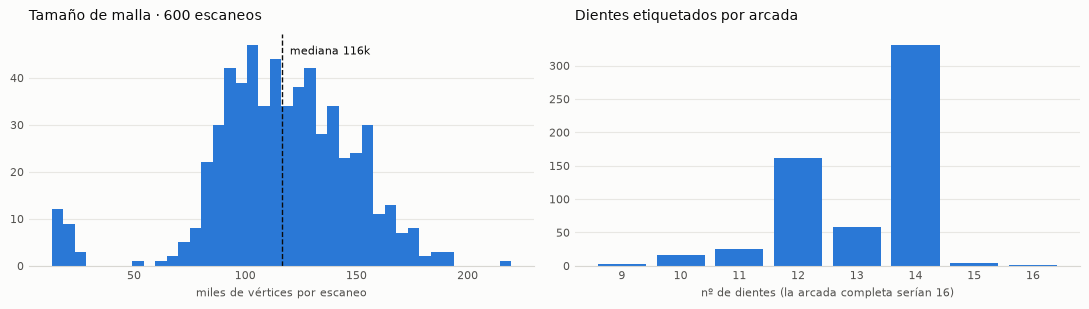

In [5]:
import matplotlib.pyplot as plt  # backend inline de Jupyter -> la figura se embebe como PNG

SURFACE, INK, INK2, BLUE, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6", "#e8e7e3"


def _estilo(ax, titulo, xlab=""):
    ax.set_facecolor(SURFACE)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#d8d7d2")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, length=0, labelsize=8)
    ax.set_title(titulo, color=INK, fontsize=10, loc="left", pad=10)
    ax.set_xlabel(xlab, color=INK2, fontsize=8)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2), facecolor=SURFACE)

ax1.hist(n_vert / 1000, bins=40, color=BLUE)
_estilo(ax1, f"Tamaño de malla · {len(CASES)} escaneos", "miles de vértices por escaneo")
mediana = np.median(n_vert) / 1000
ax1.axvline(mediana, color=INK, linewidth=1, linestyle="--")
ax1.text(mediana, ax1.get_ylim()[1] * 0.95, f"  mediana {mediana:.0f}k", color=INK, fontsize=8, va="top")

ax2.hist(n_dientes, bins=np.arange(n_dientes.min() - 0.5, n_dientes.max() + 1.5), color=BLUE, rwidth=0.82)
_estilo(ax2, "Dientes etiquetados por arcada", "nº de dientes (la arcada completa serían 16)")
ax2.set_xticks(range(int(n_dientes.min()), int(n_dientes.max()) + 1))

fig.tight_layout()
plt.show()


Y el desbalance por código FDI, que es el que tendrá que compensar el `segmentation-agent`. Cada barra es el **% de escaneos de esa arcada en los que aparece ese diente**, en orden anatómico. Las barras cortas —y sobre todo las que faltan— son las clases que el modelo apenas verá.


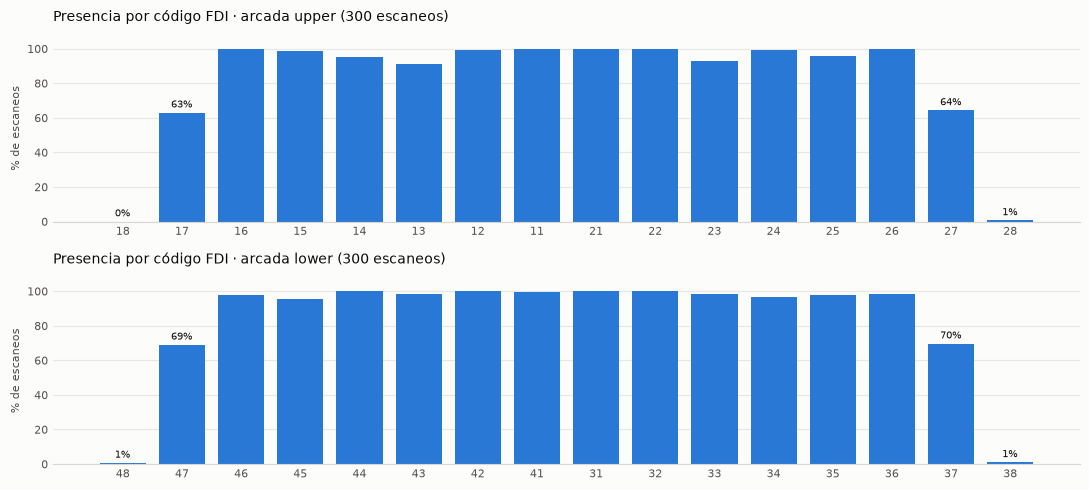

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), facecolor=SURFACE)
for ax, jaw in zip(axes, ("upper", "lower")):
    codigos = ORDEN[jaw]
    pct = [100 * pres[jaw][c] / N_JAW[jaw] for c in codigos]
    ax.bar(range(len(codigos)), pct, color=BLUE, width=0.78)
    _estilo(ax, f"Presencia por código FDI · arcada {jaw} ({N_JAW[jaw]} escaneos)")
    ax.set_xticks(range(len(codigos)))
    ax.set_xticklabels(codigos)
    ax.set_ylim(0, 108)
    ax.set_ylabel("% de escaneos", color=INK2, fontsize=8)
    # etiqueta directa solo donde la ausencia es informativa (no un numero sobre cada barra)
    for x, p in enumerate(pct):
        if p < 90:
            ax.text(x, p + 3, f"{p:.0f}%", ha="center", color=INK, fontsize=7)

fig.tight_layout()
plt.show()


## 2 · Cargar malla + labels FDI

`labels` es un array **por vértice** (mismo orden que los puntos de la malla): código ISO-FDI del diente, **`0` = encía**. Validan contra el `FDICode` del contrato.

In [7]:
def load_mesh(obj_path: Path) -> vtk.vtkPolyData:
    r = vtk.vtkOBJReader()
    r.SetFileName(str(obj_path))
    r.Update()
    return r.GetOutput()

poly = load_mesh(obj_path)
n_pts = poly.GetNumberOfPoints()
labels = np.asarray(json.load(open(json_path))["labels"], dtype=np.int32)
pts = vtk_to_numpy(poly.GetPoints().GetData())

assert len(labels) == n_pts, "labels no casan con vértices"
print(f"malla   : {n_pts:,} vértices · {poly.GetNumberOfCells():,} caras")
print(f"bbox    : min {pts.min(0).round(1)}  max {pts.max(0).round(1)} (mm)")
print(f"FDI     : {sorted(int(v) for v in np.unique(labels))}")
print(f"encía(0): {int((labels == 0).sum()):,} vértices")

# adjuntar FDI como escalares de punto para colorear
farr = numpy_to_vtk(labels.astype(float))
farr.SetName("FDI")
poly.GetPointData().SetScalars(farr)

malla   : 109,990 vértices · 219,880 caras
bbox    : min [ -44.4  -29.9 -121.3]  max [ 44.2  39.6 -82.2] (mm)
FDI     : [0, 31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46, 47]
encía(0): 36,123 vértices


0

## 3 · Render de la malla coloreada por FDI

Validación visual de que el **ancla semántica** (`region_id` FDI) está bien alineada con la geometría: cada diente = un color; la encía (0) de fondo.

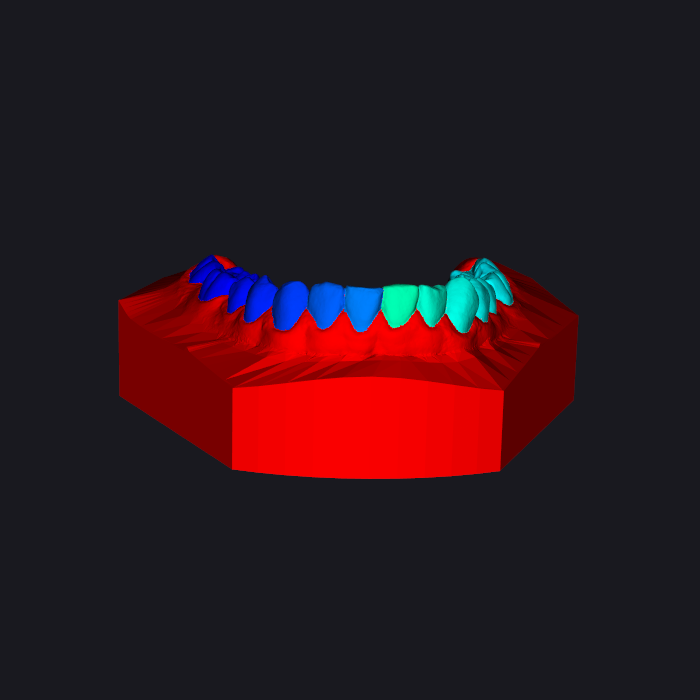

In [8]:
m = vtk.vtkPolyDataMapper()
m.SetInputData(poly)
m.SetScalarRange(0, 47)
a = vtk.vtkActor()
a.SetMapper(m)
render([a], elevation=-70)
# con esta celda se valida visualmente que la etiqueta coincide con la geometía de cada diente

## 3b · Malla (triángulos) vs. nube de puntos (vértices)

El **mismo diente** de dos formas, para ver la diferencia que sostiene el PoC:

- **Malla** (izq., wireframe): los **triángulos** que forman la superficie — vértices *conectados* por caras. Es lo que da la *forma*.
- **Nube de puntos** (der.): **solo los vértices**, sueltos. Es lo que alimenta a `vtkGaussianSplatter` — cada punto será el centro de una gaussiana.

La malla nos da la forma; los vértices son los «ladrillos» que convertimos en gaussianas, y cada uno trae pegada su etiqueta FDI.

diente FDI: 41
submalla: 3,128 vértices · 5,946 triángulos
malla (triángulos):


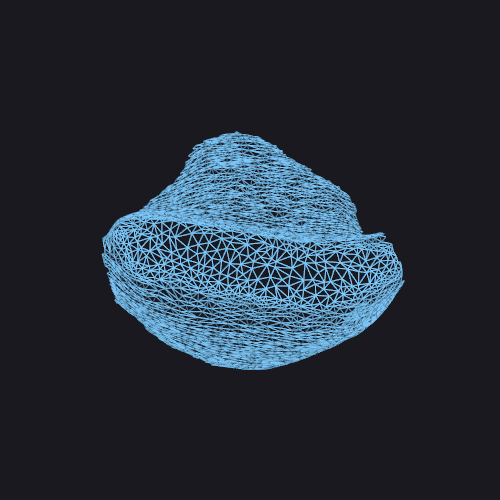

nube de puntos (vértices):


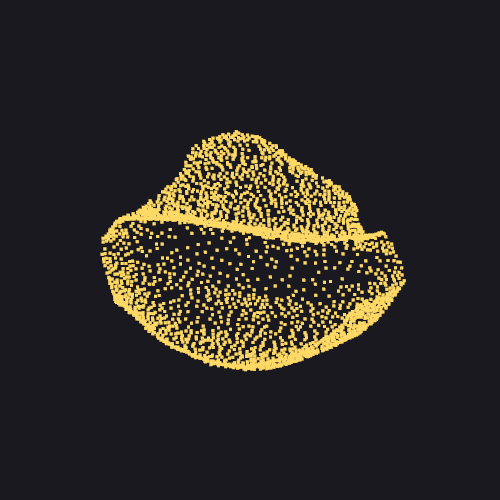

In [9]:
# Elegimos un diente presente y extraemos su submalla por la etiqueta FDI.
fdis = sorted(int(v) for v in np.unique(labels) if v != 0)
tooth = fdis[len(fdis) // 2]
print("diente FDI:", tooth)

thr = vtk.vtkThreshold()
thr.SetInputData(poly)
thr.SetInputArrayToProcess(0, 0, 0, vtk.vtkDataObject.FIELD_ASSOCIATION_POINTS, "FDI")
thr.SetLowerThreshold(tooth)
thr.SetUpperThreshold(tooth)
thr.SetAllScalars(1)  # toda la cara debe pertenecer a ese diente
thr.Update()
geo = vtk.vtkGeometryFilter()  # unstructured grid -> polydata (superficie)
geo.SetInputConnection(thr.GetOutputPort())
geo.Update()
tooth_poly = geo.GetOutput()
print(f"submalla: {tooth_poly.GetNumberOfPoints():,} vértices · {tooth_poly.GetNumberOfCells():,} triángulos")

# (a) MALLA — los triángulos (wireframe para verlos)
mm = vtk.vtkPolyDataMapper()
mm.SetInputData(tooth_poly)
mm.ScalarVisibilityOff()
mesh_actor = vtk.vtkActor()
mesh_actor.SetMapper(mm)
mesh_actor.GetProperty().SetRepresentationToWireframe()
mesh_actor.GetProperty().SetColor(0.5, 0.8, 1.0)
print("malla (triángulos):")
render([mesh_actor], size=(500, 500))

# (b) NUBE DE PUNTOS — solo los vértices (los ladrillos del splatting)
vg = vtk.vtkVertexGlyphFilter()
vg.SetInputData(tooth_poly)
vg.Update()
pm = vtk.vtkPolyDataMapper()
pm.SetInputConnection(vg.GetOutputPort())
pm.ScalarVisibilityOff()
pts_actor = vtk.vtkActor()
pts_actor.SetMapper(pm)
pts_actor.GetProperty().SetColor(1.0, 0.85, 0.4)
pts_actor.GetProperty().SetPointSize(3)
print("nube de puntos (vértices):")
render([pts_actor], size=(500, 500))

## 4 · `vtkGaussianSplatter` sobre la nube de puntos

El corazón del PoC: tomamos los vértices como **nube de puntos** y los *splatteamos* a un **campo escalar volumétrico** (cada punto siembra una gaussiana isótropa). Es el análogo clásico de la densidad σ que en RGS lleva cada primitiva (Beer-Lambert). Lo **contorneamos** (isosuperficie) para verlo.

volumen : (80, 80, 80) · rango densidad (0.0, 1.0)


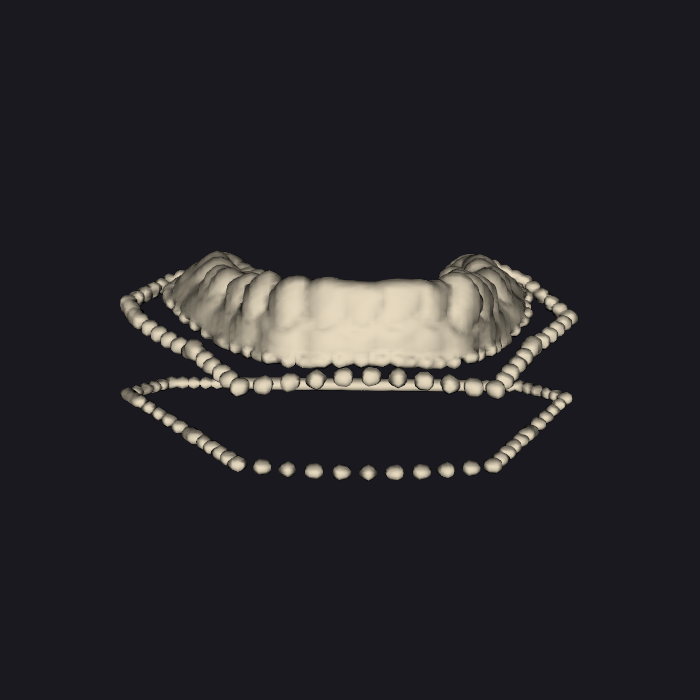

In [10]:
cloud = vtk.vtkPolyData()
cloud.SetPoints(poly.GetPoints()) # crea una nube de puntos a partir de los mismos vertices de la malla, pero sin las caras (solo puntos)
# es la entrada del splatter

splat = vtk.vtkGaussianSplatter() # siembra la gaussiana ("mancha" difusa) en cada punto y las acumula sobre la rejilla 3d
splat.SetInputData(cloud)
splat.SetSampleDimensions(80, 80, 80)  # resolución del volumen
splat.SetRadius(0.025)                 # soporte de cada gaussiana (frac. del bbox)
splat.ScalarWarpingOff()
splat.Update()
vol = splat.GetOutput()
print("volumen :", vol.GetDimensions(), "· rango densidad", tuple(round(x, 3) for x in vol.GetScalarRange()))

iso = vtk.vtkContourFilter()
iso.SetInputData(vol)
iso.SetValue(0, 0.15)
iso.Update()
im = vtk.vtkPolyDataMapper()
im.SetInputConnection(iso.GetOutputPort())
im.ScalarVisibilityOff()
ia = vtk.vtkActor()
ia.SetMapper(im)
ia.GetProperty().SetColor(0.90, 0.85, 0.75)
render([ia], elevation=-70)

## 5 · Serializar al contrato (`core-schemas`)

El fix de *«PoC sin huérfanos»*: la salida se referencia desde el contrato. Persistimos la nube como artefacto `.ply` en `data/processed/` (gitignored), la identificamos por **hash**, y construimos un `TwinSnapshot` cuyo `gaussian_field_ref` apunta a ese artefacto — exactamente el patrón del diseño (el campo masivo **no** se embebe en Pydantic; se referencia). Una muestra de `GaussianPrimitive` demuestra que la geometría + el `region_id` FDI encajan en la primitiva.

In [11]:
import sys
from datetime import datetime, timezone

sys.path.insert(0, str(ROOT / "packages/core-schemas/src"))
from core_schemas import GaussianPrimitive, Modality, Provenance, TwinSnapshot

# artefacto .ply (el "campo gaussiano" del PoC) + hash
art_dir = ROOT / "data/processed/teeth3ds"
art_dir.mkdir(parents=True, exist_ok=True)
ply_path = art_dir / f"{PID}_{JAW}_points.ply"
w = vtk.vtkPLYWriter()
w.SetFileName(str(ply_path))
w.SetInputData(cloud)
w.Write()
digest = hashlib.sha256(ply_path.read_bytes()).hexdigest()[:16]
print("artefacto:", ply_path.relative_to(ROOT), "· sha256", digest)

# muestra de primitivas (geometría + ancla FDI); region_id None para la encía
def fdi(v: int) -> str | None:
    return str(int(v)) if v != 0 else None

sample = [
    GaussianPrimitive(
        center=tuple(float(x) for x in pts[i]),
        scale=(0.02, 0.02, 0.02),
        rotation=(1.0, 0.0, 0.0, 0.0),
        density=float(0.5),
        region_id=fdi(labels[i]),
    )
    for i in range(0, n_pts, n_pts // 5)
]
print("primitivas ejemplo:", [p.region_id for p in sample])

snap = TwinSnapshot(
    acquisition_id=f"{PID}_{JAW}_poc",
    timestamp=datetime.now(timezone.utc),
    modalities=[Modality.MESH],
    gaussian_field_ref=f"ply://{ply_path.name}#sha256:{digest}",
    n_primitives=n_pts,
    provenance=Provenance(
        source_file=str(obj_path.relative_to(ROOT)),
        modality=Modality.MESH,
        agent="vtk-3dgs-poc",
        confidence=0.5,
    ),
)
print(snap.model_dump_json(indent=2))

artefacto: data/processed/teeth3ds/01A6GW4A_lower_points.ply · sha256 ed52a5fb9fd30aee
primitivas ejemplo: ['36', None, '31', '44', '34']
{
  "schema_version": "1.0.0",
  "acquisition_id": "01A6GW4A_lower_poc",
  "timestamp": "2026-07-22T10:24:37.451863Z",
  "modalities": [
    "mesh"
  ],
  "ingestion": [],
  "gaussian_field_ref": "ply://01A6GW4A_lower_points.ply#sha256:ed52a5fb9fd30aee",
  "n_primitives": 109990,
  "regional": [],
  "provenance": {
    "source_file": "data/raw/teeth3ds/3D_scans_per_patient_obj_files/01A6GW4A/01A6GW4A_lower.obj",
    "modality": "mesh",
    "agent": "vtk-3dgs-poc",
    "confidence": 0.5,
    "ingested_at": "2026-07-22T10:24:37.451894Z"
  }
}


## 6 · Barrido de robustez sobre el dataset completo

Las §§2–5 demuestran la cadena en **un** caso. Eso valida que la tubería *existe*, no que *aguanta*. Aquí la corremos entera —carga → labels → *splatting*— sobre una **muestra aleatoria reproducible** del dataset, comprobando en cada caso la invariante que sostiene todo el diseño: **`len(labels) == nº de vértices`**, el ancla semántica casa punto a punto.

De paso salen los **tiempos por escaneo**, que son el presupuesto real del futuro `mesh-agent` (y su extrapolación a los 600).


In [12]:
K = 24
rng = random.Random(0)  # muestreo reproducible: el mismo barrido en cada ejecución
muestra = rng.sample(CASES, K)


def splat_field(poly, dims=80, radius=0.025):
    """Los vértices como nube -> campo de densidad volumétrico (mismo ajuste que §4)."""
    nube = vtk.vtkPolyData()
    nube.SetPoints(poly.GetPoints())
    s = vtk.vtkGaussianSplatter()
    s.SetInputData(nube)
    s.SetSampleDimensions(dims, dims, dims)
    s.SetRadius(radius)
    s.ScalarWarpingOff()
    s.Update()
    return s.GetOutput()


print(f"{'caso':<18}{'vért.':>10}{'caras':>10}{'dientes':>9}{'carga':>8}{'splat':>8}{'ρ máx':>8}")
print("-" * 71)
t_cargas, t_splats = [], []
for pid, jaw in muestra:
    o, j = resolve_case(pid, jaw)
    t0 = time.time()
    p = load_mesh(o)
    t_load = time.time() - t0
    lab = np.asarray(json.load(open(j))["labels"], dtype=np.int32)
    # LA invariante del ancla semántica: una etiqueta por vértice, en el mismo orden
    assert len(lab) == p.GetNumberOfPoints(), f"{pid}_{jaw}: labels no casan con vértices"
    t0 = time.time()
    vol = splat_field(p)
    t_splat = time.time() - t0
    t_cargas.append(t_load)
    t_splats.append(t_splat)
    print(f"{pid + '_' + jaw:<18}{p.GetNumberOfPoints():>10,}{p.GetNumberOfCells():>10,}"
          f"{len(np.unique(lab[lab != 0])):>9}{t_load:>7.2f}s{t_splat:>7.2f}s{vol.GetScalarRange()[1]:>8.2f}")

tot = np.mean(t_cargas) + np.mean(t_splats)
print("-" * 71)
print(f"{K}/{K} casos OK · labels == vértices en todos · ninguna excepción de VTK")
print(f"media: carga {np.mean(t_cargas):.2f}s + splat {np.mean(t_splats):.2f}s = {tot:.2f}s por escaneo")
print(f"extrapolado a los {len(CASES)} escaneos: ~{tot * len(CASES) / 60:.0f} min en un solo hilo")


caso                   vért.     caras  dientes   carga   splat   ρ máx
-----------------------------------------------------------------------


949XHLS5_lower        92,268   184,399       12   0.05s   0.12s    1.00


DA6ONC9Z_lower       124,210   248,324       14   0.06s   0.15s    1.00
014F9HTN_upper       107,363   214,569       12   0.05s   0.13s    1.00


01K6HYF6_upper        24,723    49,330       13   0.01s   0.03s    1.00


R7SB5B5N_upper       141,795   283,473       14   0.08s   0.16s    1.00
NX1SXEJY_upper        25,990    51,855       14   0.01s   0.03s    1.00


...

01AS003D_upper       121,297   242,487       12   0.06s   0.14s    1.00
01JZF0KX_lower       107,767   215,424       12   0.05s   0.14s    1.00


V9CAFAV4_upper       151,260   302,404       14   0.07s   0.18s    1.00


01F4RGN8_lower       116,126   232,141       12   0.05s   0.15s    1.00
01MAU84T_upper       112,850   225,567       10   0.05s   0.14s    1.00


01AS9ER0_upper       133,354   266,560       14   0.06s   0.16s    1.00


01A6GW4A_upper       136,295   272,437       13   0.07s   0.16s    1.00
0TMOBYXS_lower        89,463   178,825       14   0.04s   0.10s    1.00
-----------------------------------------------------------------------
24/24 casos OK · labels == vértices en todos · ninguna excepción de VTK
media: carga 0.05s + splat 0.14s = 0.19s por escaneo
extrapolado a los 600 escaneos: ~2 min en un solo hilo


## 7 · Galería multi-paciente (variabilidad anatómica)

El mismo render por FDI de la §3, pero sobre **seis pacientes distintos** elegidos al azar. Es la comprobación que ningún número da: que el ancla FDI casa con la geometría **en anatomías diferentes** —arcadas superiores e inferiores, completas y con ausencias, mallas grandes y pequeñas— y no solo en el caso que elegimos para la foto bonita.


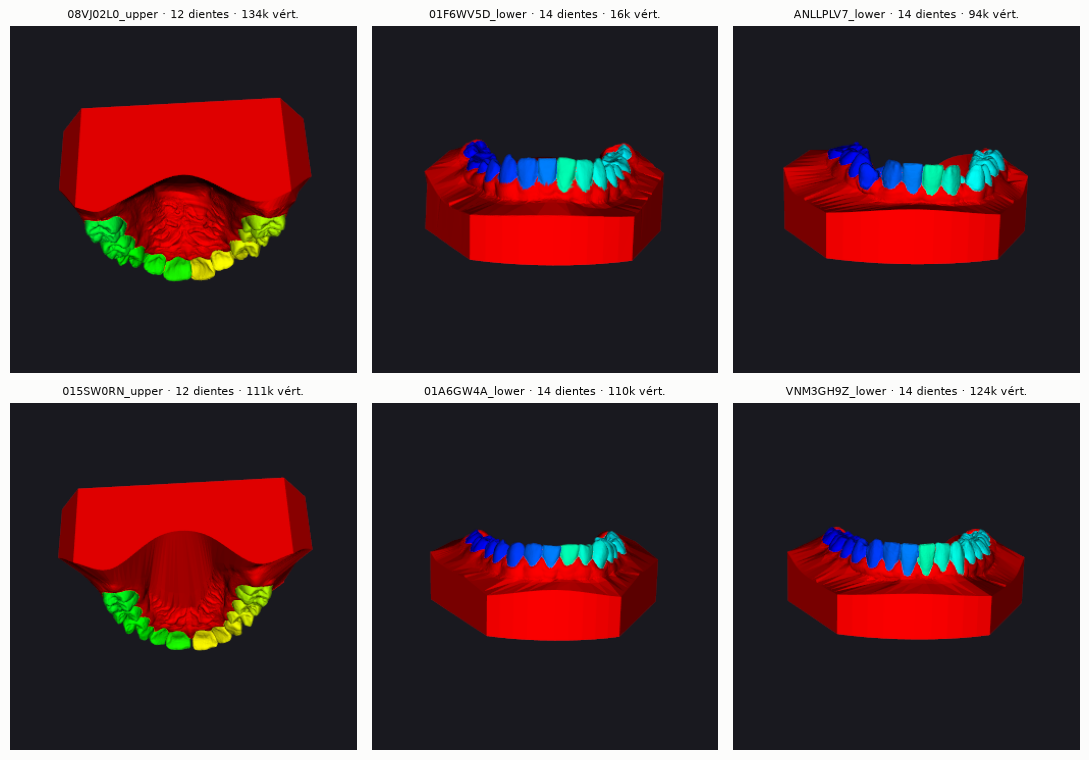

In [13]:
GAL = 6
galeria = random.Random(7).sample(CASES, GAL)

tiles, pies = [], []
for pid, jaw in galeria:
    o, j = resolve_case(pid, jaw)
    p = load_mesh(o)
    lab = np.asarray(json.load(open(j))["labels"], dtype=np.int32)
    fa = numpy_to_vtk(lab.astype(float))
    fa.SetName("FDI")
    p.GetPointData().SetScalars(fa)
    mp = vtk.vtkPolyDataMapper()
    mp.SetInputData(p)
    mp.SetScalarRange(0, 47)
    ac = vtk.vtkActor()
    ac.SetMapper(mp)
    # la superior se mira desde su plano oclusal (+70) y la inferior desde el frente (-70)
    tiles.append(render_array([ac], size=(340, 340), elevation=-70 if jaw == "lower" else 70))
    pies.append(f"{pid}_{jaw} · {len(np.unique(lab[lab != 0]))} dientes · {p.GetNumberOfPoints() / 1000:.0f}k vért.")

fig, axes = plt.subplots(2, 3, figsize=(11, 7.8), facecolor=SURFACE)
for ax, tile, pie in zip(axes.ravel(), tiles, pies):
    ax.imshow(tile)
    ax.set_title(pie, color=INK, fontsize=8, pad=6)
    ax.axis("off")
fig.tight_layout()
plt.show()


## 8 · Conclusiones (insumo para los ADR)

**Validado —y ahora sobre el dataset completo.** VTK carga las mallas Teeth3DS+, el ancla FDI casa vértice a vértice, `vtkGaussianSplatter` produce un campo de densidad volumétrico reconocible y la salida serializa limpiamente al contrato `core-schemas`. La §6 repite la cadena entera sobre **24 escaneos** aleatorios de los 600 sin una sola excepción, y la §7 la enseña sobre **seis anatomías distintas**: el resultado ya no depende del caso que elegimos.

**Lo que aporta el dataset completo (§§1b, 6, 7):**
- **El emparejamiento es una regla, no un detalle.** `list_cases()` descarta el `.obj` sin `.json`: sin ancla semántica no hay ingesta. Es literalmente el guardarraíl que hereda el `mesh-agent`.
- **El desbalance de clases está cuantificado**: la encía se lleva ~el 43% de los vértices y hay **códigos FDI que el dataset casi no contiene** —el `18` no aparece en ningún escaneo, `28`/`38`/`48` en el 1%, y los segundos molares (`17`/`27`/`37`/`47`) faltan en un tercio—. Esto justifica la **loss ponderada** del `segmentation-agent` y, sobre todo, **acota lo que se puede prometer**: un modelo entrenado aquí no segmenta cordales, porque casi nunca los ha visto. Mediana real: **14 dientes por arcada**, no 16.
- **Presupuesto de cómputo medido** (carga + splat por escaneo, con su extrapolación a los 600) — el número que hace falta para dimensionar la ingesta por lotes.

**Límites observados (insumo del ADR 002 · render):**
- `vtkGaussianSplatter` es *splatting de densidad clásico*, **no** 3DGS entrenado: gaussianas **isótropas**, sin covarianza anisótropa, sin optimización diferenciable ni armónicos esféricos. Sirve como banco de pruebas y baseline, no como motor final.
- El resultado depende mucho de `Radius` / `SampleDimensions` (coste memoria O(n³)). Para 3DGS real habrá que evaluar un motor diferenciable (SPARK / gsplat) → **D1** del diseño.
- Los `.obj` traen **color por vértice** (aún sin usar): alimenta el canal `color_superficie` (soporte superficial) cuando se aborde la fusión.

**Ganado para siguientes eslabones:**
- Los labels FDI son **ground truth de `region_id` listo** para el `segmentation-agent` y para el **ancla semántica de la fusión** (D2) — ahora con 300 pacientes detrás, no 12.
- La encía (`instance`/`label` 0) es **aislable** → base del futuro PoC de inflamación/pH (capa regional).
- El truco *«solo fotos»*: con la malla + GT se pueden **renderizar vistas sintéticas** (este mismo `render()` offscreen) para alimentar un pipeline foto→3DGS con verdad-terreno — es justo lo que hace el [notebook 03](03-synthetic-views-for-3dgs.ipynb), que ahora genera paquetes para **varios casos**.

**Siguiente:** Issue 3 (visor web three.js / GaussianSplats3D) y, tras el spike de motores, **ADR 002**.
